Ce document pour transformer le preprocessing en fonctions

In [3]:
!python.exe -m pip install --upgrade pip

In [ ]:
!python -V
!pip install seaborn

In [54]:
import pandas as pd
import pickle
import os
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error

In [6]:
!pip install pyarrow

In [ ]:
a =os.listdir()
print("Répertoire courant :", os.getcwd())
# os.chdir("~/data")
df=pd.read_parquet("green_tripdata_2021-01.parquet")

Répertoire courant : c:\Users\33664\OneDrive\Bureau\Linux\.venv\mlops


In [ ]:
df.head()

In [43]:
def preprocessing(filename:str):
    df=pd.read_parquet(filename)
    #convertir en datetime
    pd.to_datetime(df.lpep_pickup_datetime)
    pd.to_datetime(df.lpep_dropoff_datetime)
    df["duration"]=df.lpep_dropoff_datetime-df.lpep_pickup_datetime
    df["duration"]=df.duration.apply(lambda td: td.total_seconds()/60 )
    # df=df[df.trip_type==2]
    #filtrer les durées inférieurs à 60 et supérieurs à1
    ((df.duration>=1) & (df.duration<=60))
    #créer un df respectant les conditions ci-dessous
    df=df[(df.duration >=1) & (df.duration<=60)]
    categorical=['PULocationID', 'DOLocationID']
    #convertir en string pour faire du one hot encoding
    df[categorical]=df[categorical].astype(str)
    print(len(df))
    return df

In [44]:
df_train=preprocessing("green_tripdata_2021-01.parquet")
df_validation=preprocessing("green_tripdata_2021-02.parquet")

73908
61921


Training and validation function

In [57]:
def train_model(df):
    categorical=['PULocationID', 'DOLocationID']
    numerical=['trip_distance']
    train_dicts=df[categorical+numerical].to_dict(orient='records')
    #instanciation du dictvectorizer
    dv= DictVectorizer()
    X_train=dv.fit_transform(train_dicts)
    #définir la cible 
    target = "duration"
    y_train=df[target].values
    lr = LinearRegression()
    lr.fit(X_train,y_train)
    y_pred_lr=lr.predict(X_train)
    lr_lasso = Lasso()
    lr_lasso.fit(X_train,y_train)
    y_pred_la=lr_lasso.predict(X_train)
    RMSE_lr=root_mean_squared_error(y_train,y_pred_lr)
    RMSE_la=root_mean_squared_error(y_train,y_pred_la)
    with open("models/lin_reg.bin","wb") as f_out:
        pickle.dump((dv,lr),f_out)

    return {"rmse_linear_regression":RMSE_lr,"rmse_lasso":RMSE_la}

In [ ]:
train_model(df)

In [63]:
def train_model2(df):
    df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
    categorical=['PU_DO']
    numerical=['trip_distance']
    train_dicts=df[categorical+numerical].to_dict(orient='records')
    #instanciation du dictvectorizer
    dv= DictVectorizer()
    X_train=dv.fit_transform(train_dicts)
    #définir la cible 
    target = "duration"
    y_train=df[target].values
    lr = LinearRegression()
    lr.fit(X_train,y_train)
    y_pred_lr=lr.predict(X_train)
    lr_lasso = Lasso()
    lr_lasso.fit(X_train,y_train)
    y_pred_la=lr_lasso.predict(X_train)
    RMSE_lr=root_mean_squared_error(y_train,y_pred_lr)
    RMSE_la=root_mean_squared_error(y_train,y_pred_la)
    with open("models/lin_reg.bin","wb") as f_out:
        pickle.dump((dv,lr),f_out)

    return {"rmse_linear_regression":RMSE_lr,"rmse_lasso":RMSE_la}

In [68]:
train_model2(df)

KeyError: "['PU_DO'] not in index"

In [47]:
categorical=['PULocationID', 'DOLocationID']
numerical=['trip_distance']


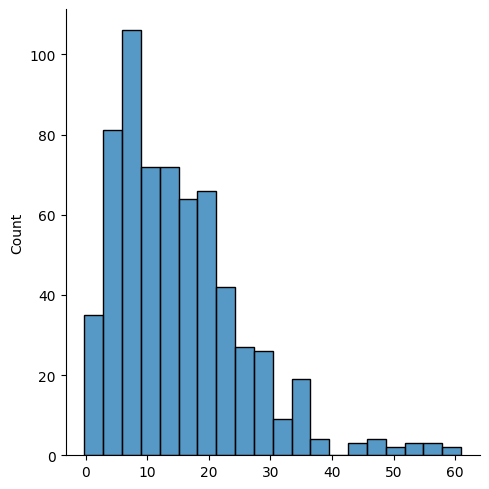

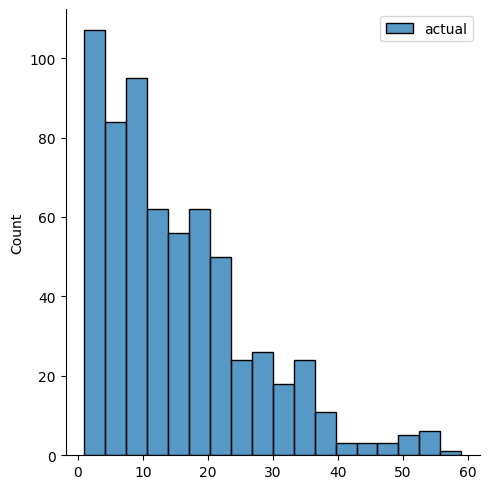

In [25]:
sns.displot(y_pred,label='prediction')
sns.displot(y_train,label='actual')
plt.legend()


In [26]:
root_mean_squared_error(y_train,y_pred)

np.float64(4.803126265704104)